In [3]:
""" Laboratorium 4: Projekt i implementacja sieci dwuwarstwowej dla wybranego zastosowania.

oznaczenia:
x1, x2 - wejścia do sieci
d - oczekiwana wartość na wyjściu
x - wektor wyjściowy z biasem [1,x1,x2]
W1 - wagi miedzy wejsciem a warstwa ukryta
W2 - wagi miedzy warstwa ukryta a wyjsciem
s1 - suma wazona w warstwie ukrytej
v1 - wyjscie z warstwy ukrytej po sigmoidalnej
v_hidden - wyjścia ukryte z biasem
y - wyjscie sieci
error - błąd
delta1 - błędy neuronów ukrytych
delta2 - bład neuroonu wyjściowego (backprop)
gamma - współczynnik uczenia
epoch - epoka
MSE - sredni bład kwadratowy"""

import numpy as np
import pandas as pd
import json
import os
import random
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

OUTPUT_DIR = "wyniki"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# tabela prawde xor
base_xor = np.array([
    [0, 0, 0],  # x1, x2 → d
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])

# 80 poprawnych
N_CORRECT = 80
correct_indices = np.random.choice(4, size=N_CORRECT, replace=True)
correct_samples = base_xor[correct_indices]

# 20 niepoprawnych
N_FAKE = 20
fake_samples = []

for _ in range(N_FAKE):
    # random para
    x1 = np.random.randint(0, 2)
    x2 = np.random.randint(0, 2)

    true_d = x1 ^ x2
    fake_d = 1 - true_d #fałszywe wartość XOR poprzez odjęcie od 1 prawdziwego outputu XORa

    fake_samples.append([x1, x2, fake_d])
fake_samples = np.array(fake_samples)

all_samples = np.vstack([correct_samples, fake_samples])

df = pd.DataFrame(all_samples, columns=["x1", "x2", "d"]) # mieszanie dancyh
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv(f"{OUTPUT_DIR}/xor_source.csv", index=False)

# podział na dane treningowe i testowe
train_size = int(0.7 * len(df))

train_data = df.iloc[:train_size].copy()
test_data  = df.iloc[train_size:].copy()
train_data.to_csv(f"{OUTPUT_DIR}/train.csv", index=False)
test_data.to_csv(f"{OUTPUT_DIR}/test.csv", index=False)

print("Train:", train_data.shape)
print("Test:", test_data.shape)

Train: (70, 3)
Test: (30, 3)


In [4]:
# funkcje aktywacji i pochodna
def sigmoid(s):
    return 1.0 / (1.0 + np.exp(-s))

def sigmoid_derivative(v):
    return v * (1 - v)

In [5]:
# uczenie sieci dwuwarstowowej (backprop)
def train_network(train_df, hidden_size=2, gamma=0.5, max_epoch=5000):
    random.seed(0)
    np.random.seed(0)
    # inicjalizacja wag: W1 (neurony ukryte) x (wejścia x1 i x2 z biasem)
    # W2 (1 neuron wyjściowy) x (neurony ukryte z biasem)
    W1 = np.random.uniform(-0.5, 0.5, size=(hidden_size, 3))
    W2 = np.random.uniform(-0.5, 0.5, size=(1, hidden_size + 1))

    mse_history = []

    print(f"\n Trenowanie przez {max_epoch} epok.")

    for epoch in range(max_epoch):
        sq_errors = []

        for i in range(len(train_df)):
            x1, x2, d = train_df.iloc[i]
            x = np.array([1, x1, x2])  # wejście z biasem

            # forward
            s1 = W1 @ x # sygn w wartw ukrytej
            v1 = sigmoid(s1) # aktywacja neuronów ukrytych

            v_hidden = np.concatenate(([1], v1)) # bias dla warstwy wejściowej
            y = sigmoid(W2 @ v_hidden)[0] # wyniki sieci

            # błąd
            error = d - y
            sq_errors.append(error**2) # dodanie do sumy kwadratów błędów

            # backprop
            # delta2=(d−y)sigmoid′(y)
            # delta1=sigmoid(v1)*(W2bez biasu * delta2)
            delta2 = error * sigmoid_derivative(y)
            delta1 = sigmoid_derivative(v1) * (W2[0, 1:] * delta2)

            # aktualizacja wag
            W2 += gamma * delta2 * v_hidden.reshape(1, -1)
            for j in range(hidden_size):
                W1[j] += gamma * delta1[j] * x
            # MSE
        mse = np.mean(sq_errors)
        mse_history.append(mse)

        if epoch % 500 == 0 or epoch == max_epoch - 1:
            print(f"Epoka {epoch} / {max_epoch}   Błąd: {mse:.6f}")

    print(f"Zakonczono trenowanie dla max_epoch = {max_epoch}, finalny błąd = {mse_history[-1]:.6f}")
    return W1, W2, mse_history


In [6]:
def test_network(W1, W2, test_df):

    print("\ntesowanie sieci")

    results = []
    correct = 0

    for i in range(len(test_df)):
        x1, x2, d = test_df.iloc[i]
        x = np.array([1, x1, x2])

        s1 = W1 @ x
        v1 = sigmoid(s1)
        v_hidden = np.concatenate(([1], v1))

        y = sigmoid(W2 @ v_hidden)[0]
        y_class = 1 if y >= 0.5 else 0

        print(f"x1={x1}, x2={x2}, expected={d}, y={y:.4f}, class={y_class}")

        if y_class == d:
            correct += 1

        results.append({
            "x1": x1,
            "x2": x2,
            "expected": d,
            "y": float(y),
            "class": y_class
        })

    accuracy = correct / len(test_df)
    print(f"\naccuracy: {accuracy:.2f}")

    return results, accuracy

In [7]:
# eksperymenty dla różnych epok
EPOCHS = [1000, 5000, 10000, 20000, 50000]
all_mse_histories = {}

with open(f"{OUTPUT_DIR}/errors.txt", "w") as ferr, \
     open(f"{OUTPUT_DIR}/weights.txt", "w") as fw, \
     open(f"{OUTPUT_DIR}/test_results.txt", "w") as fres:

    for max_epoch in EPOCHS:

        W1, W2, mse_history = train_network(train_data, max_epoch=max_epoch)
        all_mse_histories[max_epoch] = mse_history

        # zapis błędów
        ferr.write(f"\n EPOKI = {max_epoch}=\n")
        for i in range(0, max_epoch, max_epoch // 10):
            ferr.write(f"Epoka {i}: {mse_history[i]}\n")
        ferr.write(f"Finalny błąd: {mse_history[-1]}\n")

        # zapis wag
        fw.write(f"\nEPOKI = {max_epoch} =\nW1:\n{W1}\nW2:\n{W2}\n")

        # testowanie
        results, acc = test_network(W1, W2, test_data)
        fres.write(f"\n= EPOKI = {max_epoch} ===\nAccuracy={acc}\n")
        fres.write(json.dumps(results, indent=2) + "\n")

        # pełny zapis wag + błędów w json
        with open(f"{OUTPUT_DIR}/final_weights_epochs_{max_epoch}.json", "w") as fjs:
            json.dump({
                "epochs": max_epoch,
                "W1": W1.tolist(),
                "W2": W2.tolist(),
                "mse": mse_history,
                "accuracy": acc
            }, fjs, indent=2)


 Trenowanie przez 1000 epok.
Epoka 0 / 1000   Błąd: 0.261885
Epoka 500 / 1000   Błąd: 0.136567
Epoka 999 / 1000   Błąd: 0.136360
Zakonczono trenowanie dla max_epoch = 1000, finalny błąd = 0.136360

tesowanie sieci
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=1, x2=0, expected=1, y=0.6965, class=1
x1=0, x2=1, expected=0, y=0.9430, class=1
x1=1, x2=1, expected=0, y=0.1989, class=0
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=1, x2=0, expected=0, y=0.6965, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=0, x2=0, expected=0, y=0.1268, class=0
x1=1, x2=0, expected=0, y=0.6965, class=1
x1=1, x2=1, expected=0, y=0.1989, class=0
x1=1, x2=1, expected=0, y=0.1989, class=0
x1=1, x2=0, expected=1, y=0.6965, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=0, x2=1, expected=1, y=0.9430, class=1
x1=1, x2=1, expected=0, y=0.1989, class=0
x1=1, x2=0, expected=1, y=0.6

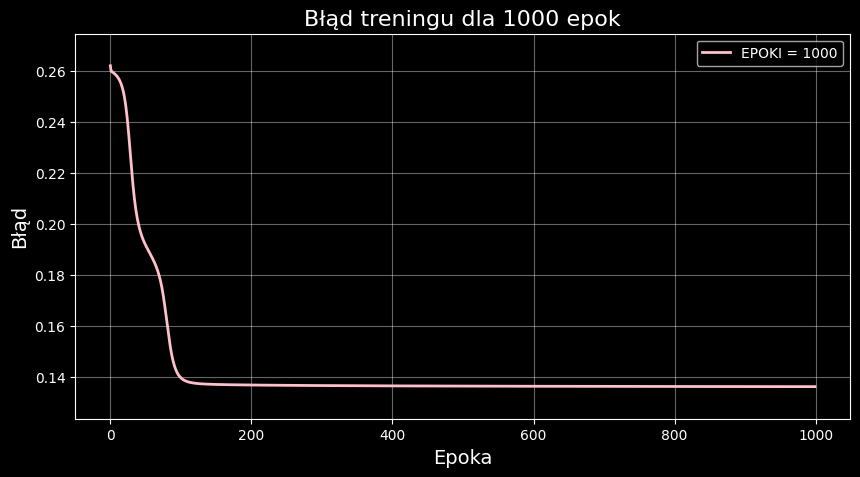

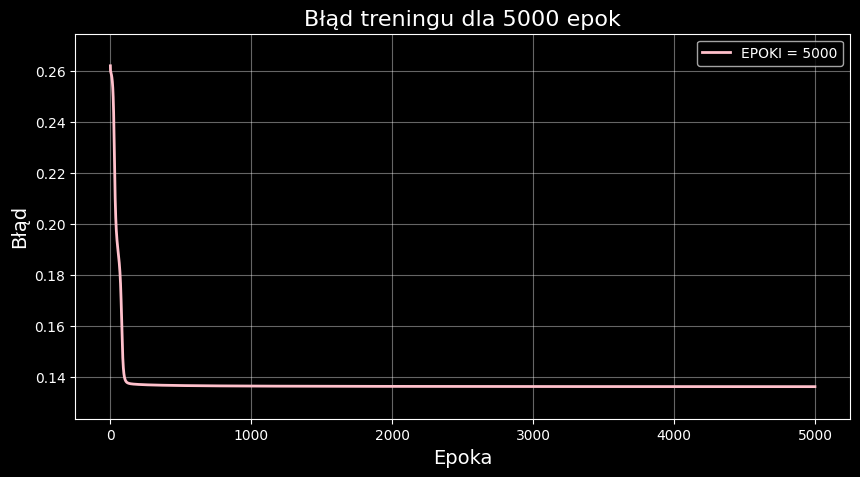

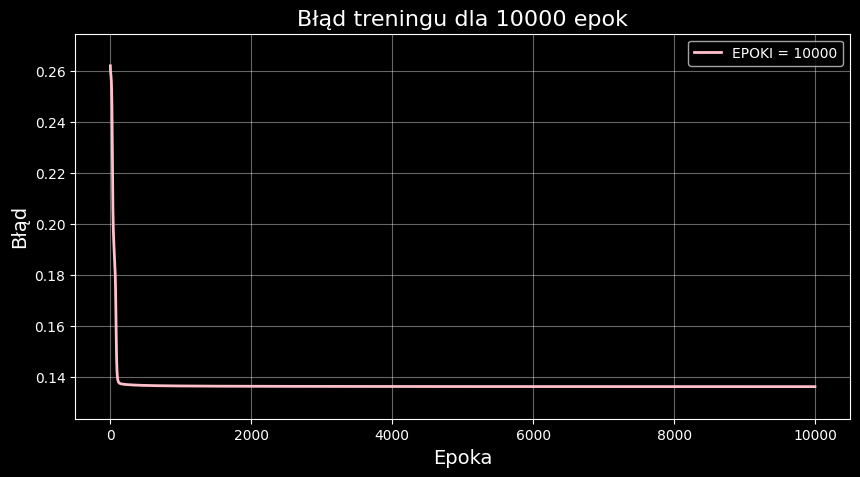

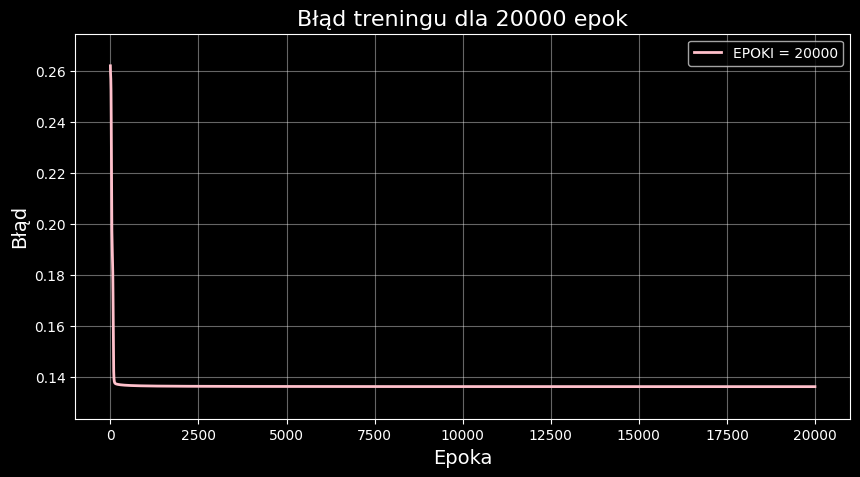

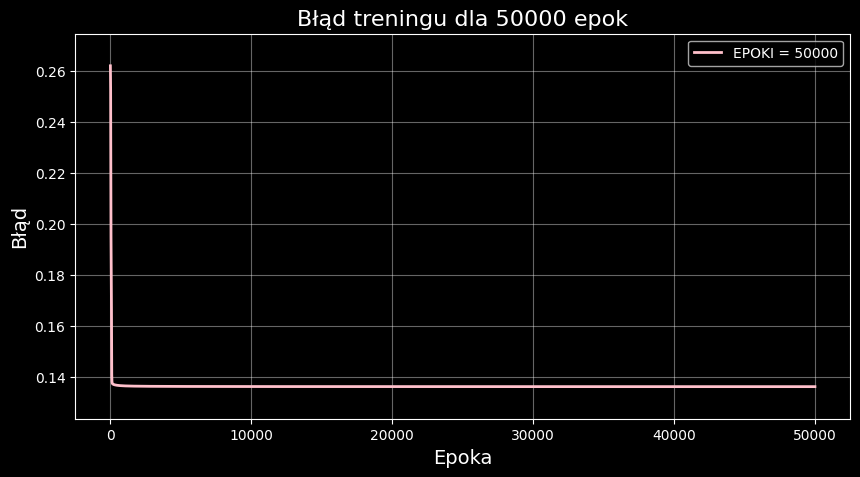

In [8]:
# wykresy błędów dla epok
plt.style.use("dark_background")

for max_epoch, history in all_mse_histories.items():
    history = np.array(history)

    ymin = history.min()
    ymax = history.max()
    margin = (ymax - ymin) * 0.1 if ymax != ymin else 0.0001

    plt.figure(figsize=(10, 5))
    plt.plot(history, label=f"EPOKI = {max_epoch}", linewidth=2, color="pink")
    plt.title(f"Błąd treningu dla {max_epoch} epok", fontsize=16)
    plt.xlabel("Epoka", fontsize=14)
    plt.ylabel("Błąd", fontsize=14)
    plt.grid(True, alpha=0.4)
    plt.legend()

    plt.ylim(ymin - margin, ymax + margin)

    plt.show()